# Forecasting Yellowfin Tuna in the Pacific Islands

In [1]:
pip install prophet

In [2]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 16.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Data Description and Load Data

* YY = Tahun. Ini adalah representasi tahun data tangkapan ikan.
* MM = Bulan. Ini adalah representasi bulan dalam data tangkapan ikan.
* LAT5 = Latitude
* LON5 = Longitude.
* CWP_GRID = Nomor Coordinating Working Party.
* HHOOKS = Jumlah kail.
* ALB_C = Tangkapan Albacore (dalam ton metrik).
* ALB_N = Tangkapan Albacore (dalam angka).
* YFT_C = Tangkapan Yellowfin (dalam ton metrik).
* YFT_N = Tangkapan Yellowfin (dalam angka).
* BET_C = Tangkapan Bigeye (dalam ton metrik).
* BET_N = Tangkapan Bigeye (dalam angka).
* MLS_C = Tangkapan Striped Marlin (dalam ton metrik).
* MLS_N = Tangkapan Striped Marlin (dalam angka).
* BLM_C = Tangkapan Black Marlin (dalam ton metrik).
* BLM_N = Tangkapan Black Marlin (dalam angka).
* BUM_C = Tangkapan Blue Marlin (dalam ton metrik).
* BUM_N = Tangkapan Blue Marlin (dalam angka).
* SWO_C = Tangkapan Swordfish (dalam ton metrik).
* SWO_N = Tangkapan Swordfish (dalam angka).
* OTH_C = Tangkapan spesies lain (dalam ton metrik).
* OTH_N =  Jumlah total tangkapan spesies lain (dalam angka).

## Load Data

In [5]:
# Read CSV into DataFrame
tuna_df = pd.read_csv('/content/LONGLINE.CSV')

# Display first 5 rows
tuna_df.head()

,yy,mm,lat5,lon5,cwp_grid,hhooks,alb_c,alb_n,yft_c,yft_n,...,mls_c,mls_n,blm_c,blm_n,bum_c,bum_n,swo_c,swo_n,oth_c,oth_n
0,1950,6,00N,140E,61000014000,1952.0,0.0,0,121.627,4796,...,0.0,0,0.0,0,62.717,1073,0.0,0,0.0,0
1,1950,6,00N,145E,61000014500,1359.0,0.0,0,94.720,3735,...,0.0,0,0.0,0,44.422,760,0.0,0,0.0,0
2,1950,6,05N,140E,61050014000,0.0,0.0,0,0.000,0,...,0.0,0,0.0,0,0.000,0,0.0,0,0.0,0
3,1950,6,05N,145E,61050014500,0.0,0.0,0,0.000,0,...,0.0,0,0.0,0,0.000,0,0.0,0,0.0,0
4,1950,6,05N,150E,61050015000,0.0,0.0,0,0.000,0,...,0.0,0,0.0,0,0.000,0,0.0,0,0.0,0


# Data Processing

In [6]:
# DataFrame summary
tuna_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156212 entries, 0 to 156211
Data columns (total 22 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   yy        156212 non-null  int64  
 1   mm        156212 non-null  int64  
 2   lat5      156212 non-null  object 
 3   lon5      156212 non-null  object 
 4   cwp_grid  156212 non-null  int64  
 5   hhooks    156212 non-null  float64
 6   alb_c     156212 non-null  float64
 7   alb_n     156212 non-null  int64  
 8   yft_c     156212 non-null  float64
 9   yft_n     156212 non-null  int64  
 10  bet_c     156212 non-null  float64
 11  bet_n     156212 non-null  int64  
 12  mls_c     156212 non-null  float64
 13  mls_n     156212 non-null  int64  
 14  blm_c     156212 non-null  float64
 15  blm_n     156212 non-null  int64  
 16  bum_c     156212 non-null  float64
 17  bum_n     156212 non-null  int64  
 18  swo_c     156212 non-null  float64
 19  swo_n     156212 non-null  int64  
 20  oth_

1. This dataset has 156,212 rows and 22 columns.
2. The columns yy and mm need to be converted into a datetime format. Since there is no date column, the first day of each month will be added as the default.
3. lat5 (Latitude) and lon5 (Longitude) record the location coordinates in the fish catch data, but both are of the object data type. Typically, this data type is used for string data, not numbers, which could indicate an issue, as geographic coordinates should be in a numeric format (float or double).
4. hhooks represents the number of hooks used in the fishing process, and it should not have decimals, but rather be an integer.


**Add a new column and change the data type**

In [7]:
# Function to convert latitude and longitude format to numbers
def convert_to_numeric(coord):
    degree = int(coord[:-1])  # Take the degree value
    direction = coord[-1]     # Take the direction (N/S/E/W)

    if direction == 'S' or direction == 'W':
        degree = -degree  # If the direction is South (S) or West (W), make the value negative

    return degree

In [8]:
# Convert column to numeric
tuna_df['latitude'] = tuna_df['lat5'].apply(convert_to_numeric)
tuna_df['longitude'] = tuna_df['lon5'].apply(convert_to_numeric)

# Convert 'yy' and 'mm' to datetime (first day of the month)
tuna_df['date'] = pd.to_datetime(tuna_df['yy'].astype(str) + '-' + tuna_df['mm'].astype(str) + '-01')

# Convert 'hhooks' to int
tuna_df['hhooks'] = tuna_df['hhooks'].astype(int)

# Convert 'cwp_grid' to object
tuna_df['cwp_grid'] = tuna_df['cwp_grid'].astype('object')

# Combine 'latitude' and 'longitude' into 'location'
tuna_df['location'] = tuna_df['latitude'].astype(str) + '°, ' + tuna_df['longitude'].astype(str) + '°'



In [9]:
tuna_df.head()

,yy,mm,lat5,lon5,cwp_grid,hhooks,alb_c,alb_n,yft_c,yft_n,...,bum_c,bum_n,swo_c,swo_n,oth_c,oth_n,latitude,longitude,date,location
0,1950,6,00N,140E,61000014000,1952,0.0,0,121.627,4796,...,62.717,1073,0.0,0,0.0,0,0,140,1950-06-01,"0°, 140°"
1,1950,6,00N,145E,61000014500,1359,0.0,0,94.720,3735,...,44.422,760,0.0,0,0.0,0,0,145,1950-06-01,"0°, 145°"
2,1950,6,05N,140E,61050014000,0,0.0,0,0.000,0,...,0.000,0,0.0,0,0.0,0,5,140,1950-06-01,"5°, 140°"
3,1950,6,05N,145E,61050014500,0,0.0,0,0.000,0,...,0.000,0,0.0,0,0.0,0,5,145,1950-06-01,"5°, 145°"
4,1950,6,05N,150E,61050015000,0,0.0,0,0.000,0,...,0.000,0,0.0,0,0.0,0,5,150,1950-06-01,"5°, 150°"


**Create a location column**

# Data Cleaning

## Remove Redundant Columns, Check for Null and Missing Values

In [10]:
tuna_df = tuna_df.drop(columns=['lat5', 'lon5', 'latitude', 'longitude'])

In [11]:
tuna_df.isna().sum()

,0
yy,0
mm,0
cwp_grid,0
hhooks,0
alb_c,0
alb_n,0
yft_c,0
yft_n,0
bet_c,0
bet_n,0


**Dataset is complete, and there is no need for handling missing values**

In [12]:
num_duplicates = tuna_df.duplicated().sum()
num_duplicates

0

**There are no duplicates**

## Remove incomplete data

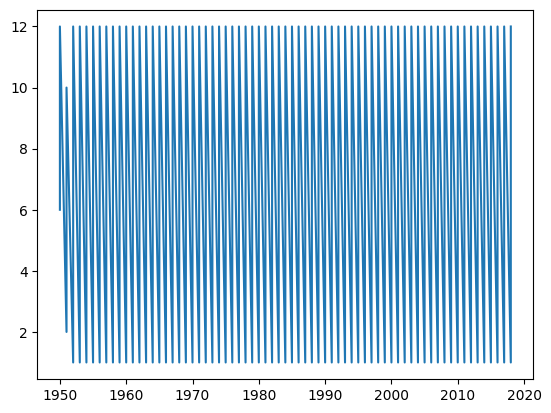

In [13]:
plt.plot(tuna_df['yy'], tuna_df['mm']) # Check the completeness of the datetime data
plt.show()

**It appears that the years 1950 and 1951 do not have complete months for the entire year (12 months)**

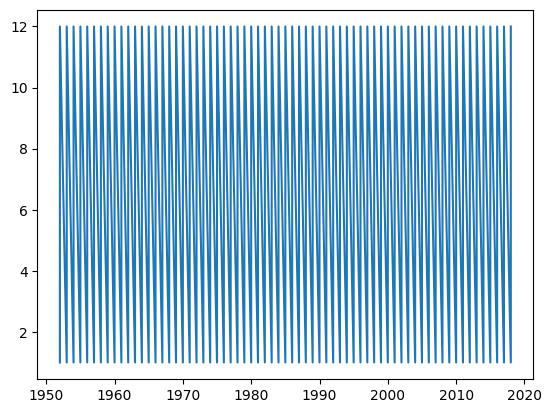

In [14]:
tuna_df = tuna_df[tuna_df['yy'] >= 1952]
plt.plot(tuna_df['yy'], tuna_df['mm'])
plt.show()

# Exploratory Data Analysis

In [15]:
tuna_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156100 entries, 112 to 156211
Data columns (total 22 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   yy        156100 non-null  int64         
 1   mm        156100 non-null  int64         
 2   cwp_grid  156100 non-null  object        
 3   hhooks    156100 non-null  int64         
 4   alb_c     156100 non-null  float64       
 5   alb_n     156100 non-null  int64         
 6   yft_c     156100 non-null  float64       
 7   yft_n     156100 non-null  int64         
 8   bet_c     156100 non-null  float64       
 9   bet_n     156100 non-null  int64         
 10  mls_c     156100 non-null  float64       
 11  mls_n     156100 non-null  int64         
 12  blm_c     156100 non-null  float64       
 13  blm_n     156100 non-null  int64         
 14  bum_c     156100 non-null  float64       
 15  bum_n     156100 non-null  int64         
 16  swo_c     156100 non-null  float64       

In [16]:
# Get list of numeric columns
num_cols = tuna_df.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()

# Get list of categorical columns
cat_cols = tuna_df.select_dtypes(include=['object']).columns.tolist()

In [17]:
tuna_df[num_cols].describe()

,yy,mm,hhooks,alb_c,alb_n,yft_c,yft_n,bet_c,bet_n,mls_c,mls_n,blm_c,blm_n,bum_c,bum_n,swo_c,swo_n,oth_c,oth_n
count,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000,156100.000000
mean,1987.949673,6.503216,2193.505272,21.093942,1434.705259,27.926091,1015.303876,23.429346,624.452223,2.746181,42.645669,0.603979,12.176393,3.903630,70.463863,5.416616,95.019910,8.202984,476.964183
std,18.704242,3.444909,4707.657482,73.263907,5071.446650,74.935003,2855.107554,60.040367,1530.956189,14.606841,199.435263,4.096816,96.329696,12.036632,216.120982,25.339499,466.677151,71.342126,2808.283334
min,1952.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1972.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1989.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2005.000000,9.000000,2576.000000,3.779000,229.000000,19.293750,678.000000,20.917000,606.000000,0.681000,13.000000,0.067000,1.000000,2.981000,51.000000,2.079000,36.000000,0.719000,48.000000
max,2018.000000,12.000000,464553.000000,2641.909000,145295.000000,1985.369000,238978.000000,3340.571000,92721.000000,1036.786000,13463.000000,375.015000,11082.000000,765.647000,12321.000000,1479.167000,31239.000000,8151.330000,147992.000000


* **The year (yy) indicates a data range from 1952 to 2018, with an average year around 1988, suggesting that most of the data is concentrated in the last few decades.**
* **The month (mm) has an average value of around 6.5, meaning that most of the data covers the month of June (the 6th month). This may indicate that the peak catch period occurs in certain seasons.**
* **There are 3 tuna species that dominate based on weight and number, namely yellowfin, albacore, and big eye.**
* **The largest catch numbers are dominated by the 75th percentile, which reinforces the idea that fishing efforts have been more intensive in the last two decades.**
"""

In [18]:
tuna_df[cat_cols].describe()

,cwp_grid,location
count,156100,156100
unique,392,392
top,61250012500,"25°, 125°"
freq,802,802


* **There are 392 fishing locations.**
* **The location with the highest fishing activity is at 25° latitude, 125° longitude.**

**Almost all columns have outliers, and the data is above 0. This is because the column containing outliers comes from the catch data and fishing effort (hooks), where the high variability in these numbers can lead to extreme values that are far from the other data points.**

## Univariate Analysis

### Total Catch Comparison and Proportion of All Species by Weight

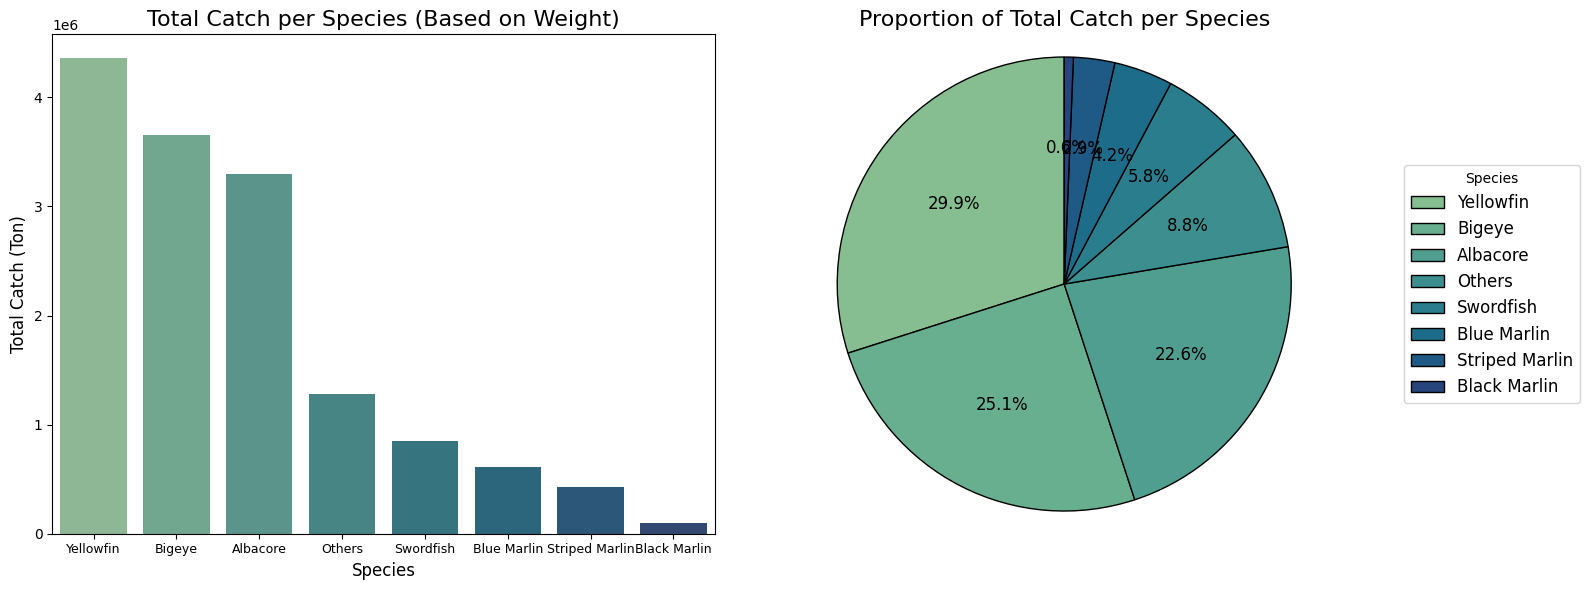

In [50]:
# Columns containing the weight of catches for each species
weight = ['alb_c', 'yft_c', 'bet_c', 'mls_c', 'blm_c', 'bum_c', 'swo_c', 'oth_c']

# Mapping column names to species names
species_weight = {
    'alb_c': 'Albacore',
    'yft_c': 'Yellowfin',
    'bet_c': 'Bigeye',
    'mls_c': 'Striped Marlin',
    'blm_c': 'Black Marlin',
    'bum_c': 'Blue Marlin',
    'swo_c': 'Swordfish',
    'oth_c': 'Others'
}

# Calculate the total catch for each species based on weight
total_catch_per_species = tuna_df[weight].sum()

# Calculate the total catch for all species
total_catch_all_species = total_catch_per_species.sum()

# Calculate the proportion of each species' catch relative to the total catch
proportion_per_species = total_catch_per_species / total_catch_all_species

# Create a DataFrame to display the results, using species labels as the index
catch_comparison_df = pd.DataFrame({
    'Total Catch (Ton)': total_catch_per_species,
    'Proportion': proportion_per_species
}).sort_values(by='Total Catch (Ton)', ascending=False)

# Rename the index using species labels
catch_comparison_df.index = [species_weight[species] for species in catch_comparison_df.index]

# Create a blue-to-yellow gradient color palette
colors = sns.color_palette("crest", len(catch_comparison_df))

# Create a figure with 2 subplots side by side (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar Chart (Total Catch per Species)
ax[0].set_title('Total Catch per Species (Based on Weight)', fontsize=16)
sns.barplot(x=catch_comparison_df.index, y=catch_comparison_df['Total Catch (Ton)'], palette=colors, ax=ax[0])
ax[0].set_xlabel('Species', fontsize=12)
ax[0].set_ylabel('Total Catch (Ton)', fontsize=12)
ax[0].tick_params(axis='x')  # Rotate labels for better readability
ax[0].tick_params(axis='x', labelsize=9)

# Plot 2: Pie Chart (Proportion of Total Catch per Species) without labels
ax[1].set_title('Proportion of Total Catch per Species', fontsize=16)
wedges, texts, autotexts = ax[1].pie(
    catch_comparison_df['Proportion'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12, 'color': 'black'},
    wedgeprops={'edgecolor': 'black'}
)

# Add legend for species
ax[1].legend(wedges, catch_comparison_df.index, title="Species", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12)

ax[1].axis('equal')  # Ensure the pie chart is circular

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plot
plt.show()




**Based on their significant contributions to the total catch, it can be concluded that the primary target species in the Pacific Islands are yellowfin, bigeye, and albacore. These three species dominate the catch, with yellowfin contributing 29.9%, bigeye 25.1%, and albacore 22.6%.**

In [20]:
print(catch_comparison_df)

                Total Catch (Ton)  Proportion
Yellowfin             4359262.814    0.299242
Bigeye                3657320.963    0.251057
Albacore              3292764.324    0.226032
Others                1280485.862    0.087899
Swordfish              845533.823    0.058042
Blue Marlin            609356.612    0.041829
Striped Marlin         428678.834    0.029427
Black Marlin            94281.118    0.006472


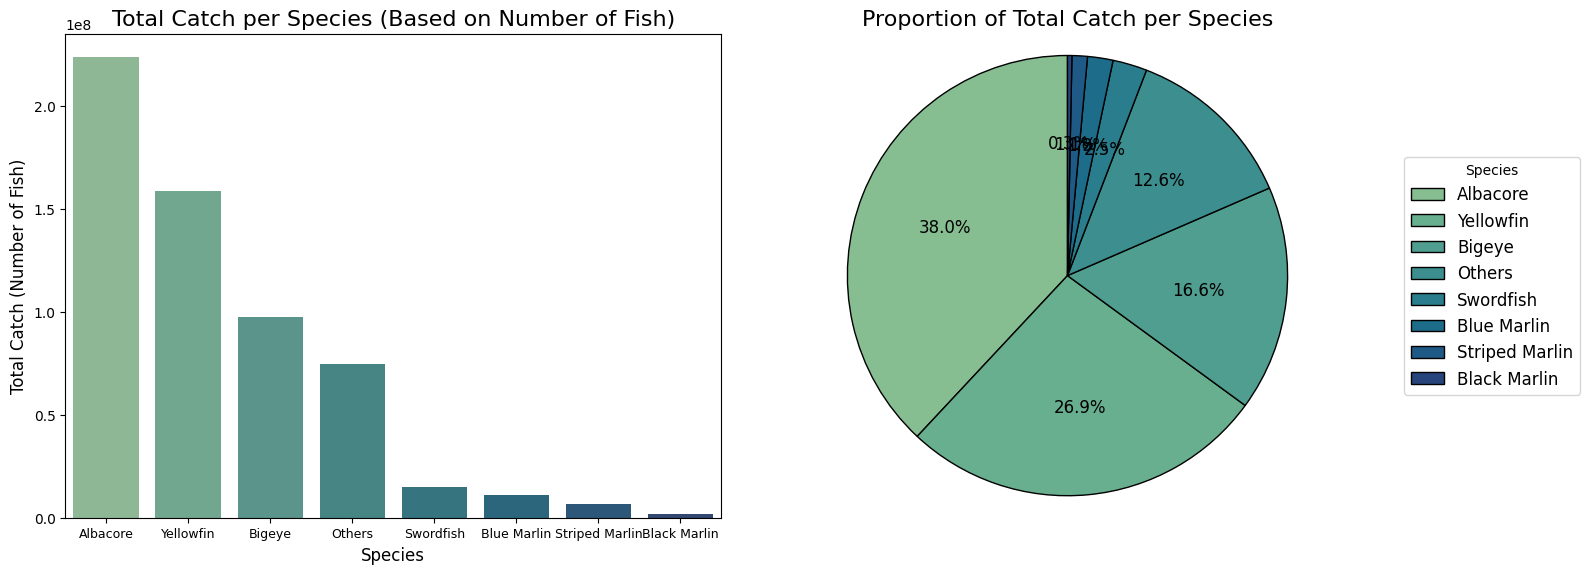

In [51]:
# Columns containing the number of fish catches for each species
count = ['alb_n', 'yft_n', 'bet_n', 'mls_n', 'blm_n', 'bum_n', 'swo_n', 'oth_n']

# Mapping column names to species names
species_count = {
    'alb_n': 'Albacore',
    'yft_n': 'Yellowfin',
    'bet_n': 'Bigeye',
    'mls_n': 'Striped Marlin',
    'blm_n': 'Black Marlin',
    'bum_n': 'Blue Marlin',
    'swo_n': 'Swordfish',
    'oth_n': 'Others'
}

# Calculate the total number of fish caught for each species
total_catch_per_species_count = tuna_df[count].sum()

# Calculate the total number of fish for all species
total_catch_all_species_count = total_catch_per_species_count.sum()

# Calculate the proportion of each species' catch relative to the total catch
proportion_per_species_count = total_catch_per_species_count / total_catch_all_species_count

# Create a DataFrame to display the results, using species labels as the index
catch_comparison_df_count = pd.DataFrame({
    'Total Catch (Number of Fish)': total_catch_per_species_count,
    'Proportion': proportion_per_species_count
}).sort_values(by='Total Catch (Number of Fish)', ascending=False)

# Rename the index using species labels
catch_comparison_df_count.index = [species_count[species] for species in catch_comparison_df_count.index]

# Create a blue-to-yellow gradient color palette
colors = sns.color_palette("crest", len(catch_comparison_df_count))

# Create a figure with 2 subplots side by side (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar Chart (Total Catch per Species)
ax[0].set_title('Total Catch per Species (Based on Number of Fish)', fontsize=16)
sns.barplot(x=catch_comparison_df_count.index, y=catch_comparison_df_count['Total Catch (Number of Fish)'],
            palette=colors, ax=ax[0])
ax[0].set_xlabel('Species', fontsize=12)
ax[0].set_ylabel('Total Catch (Number of Fish)', fontsize=12)
ax[0].tick_params(axis='x', labelsize=9)  # Rotate labels for better readability

# Plot 2: Pie Chart (Proportion of Total Catch per Species) without labels
ax[1].set_title('Proportion of Total Catch per Species', fontsize=16)
wedges, texts, autotexts = ax[1].pie(
    catch_comparison_df_count['Proportion'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 12, 'color': 'black'},
    wedgeprops={'edgecolor': 'black'}
)

# Add legend for species
ax[1].legend(wedges, catch_comparison_df_count.index, title="Species", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12)

ax[1].axis('equal')  # Ensure the pie chart is circular

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plot
plt.show()


**The dominant species are still the same, but there is a difference in the order. This indicates a difference in the size of each fish, with yellowfin having the largest size.**

## Total Catch per Year by All Species

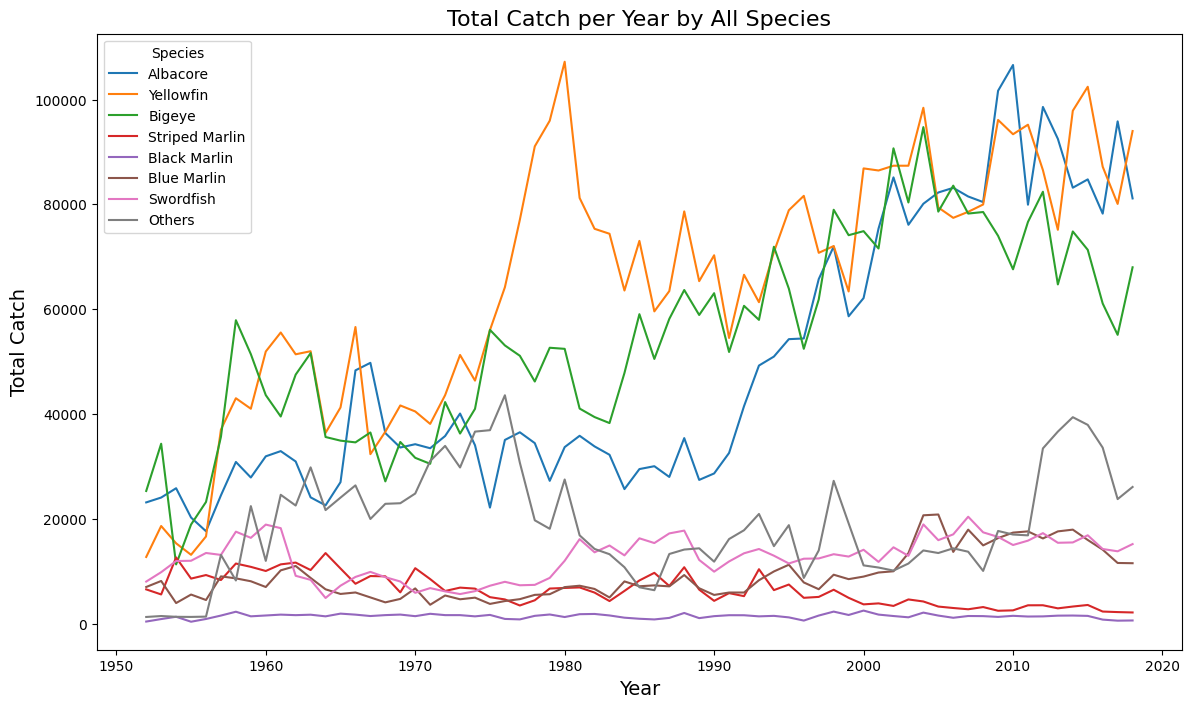

In [22]:
# Group by 'yy' and sum species weights
yearly_catch = tuna_df.groupby('yy')[list(species_weight.keys())].sum().reset_index()

# Group by 'yy' and sum catch data for specific species
yearly_catch = tuna_df.groupby('yy')[['alb_c', 'yft_c', 'bet_c', 'mls_c', 'blm_c', 'bum_c', 'swo_c', 'oth_c']].sum().reset_index()

# Create a visualization of total catch per year
plt.figure(figsize=(14, 8))
for species, label in species_weight.items():
    sns.lineplot(data=yearly_catch, x='yy', y=species, label=label)
plt.title('Total Catch per Year by All Species', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Total Catch', fontsize=14)
plt.legend(title='Species')
plt.show()

* **High Fluctuations:** The graph shows significant fluctuations in fish catches each year, influenced by weather, market demand, and fisheries policies.

* **General Increase:** Fish catches increased until the 1980s, then declined significantly, but have risen again in the last 20 years, although still fluctuating.

## Monthly Average Catch by Species

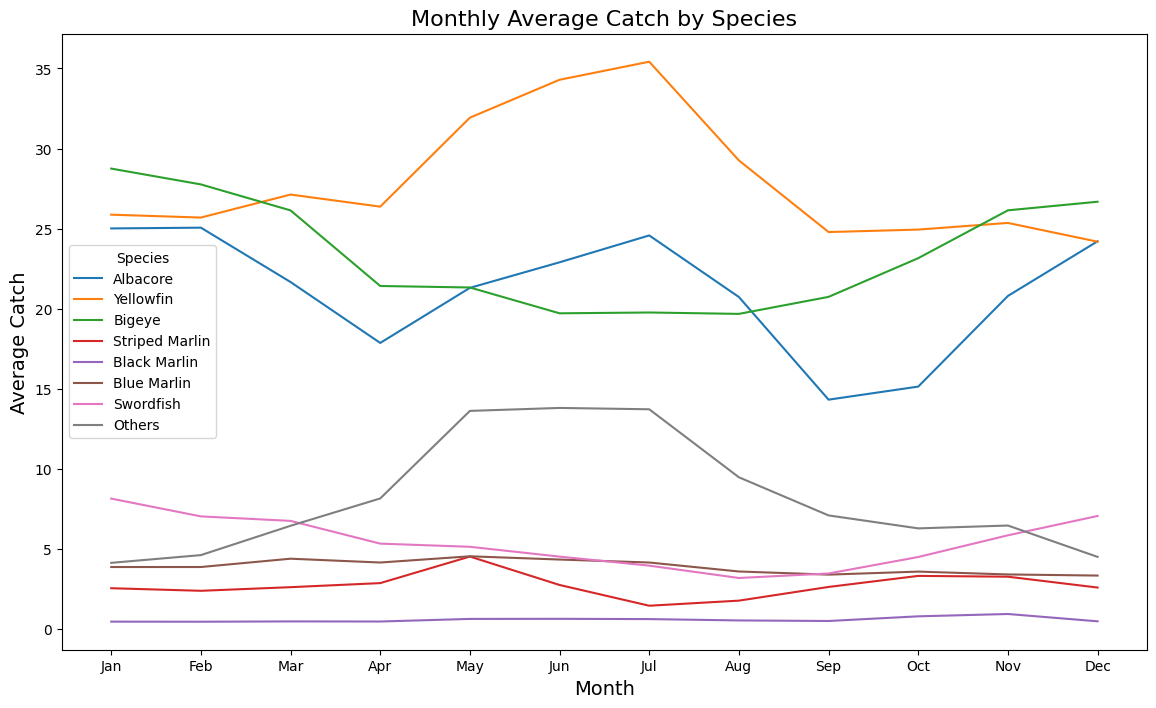

In [23]:
# Group by 'mm' and calculate the monthly average catch for specific species
monthly_avg_catch = tuna_df.groupby('mm')[['alb_c', 'yft_c', 'bet_c', 'mls_c', 'blm_c', 'bum_c', 'swo_c', 'oth_c']].mean().reset_index()

# Create a visualization of monthly average catch
plt.figure(figsize=(14, 8))
for species, label in species_weight.items():
    sns.lineplot(data=monthly_avg_catch, x='mm', y=species, label=label)  # Draw line for each species
plt.title('Monthly Average Catch by Species', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Catch', fontsize=14)
plt.xticks(ticks=range(1, 13), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
])  # Add month labels
plt.legend(title='Species')
plt.show()

**Monthly Fluctuations:** The graph shows significant fluctuations in the average monthly catch for each species, indicating the presence of seasonal patterns in fishing.

**Dominance of Several Species:** Similar to the annual graph, yellowfin tuna and albacore remain the species with the highest monthly catches.

**Different Seasonal Patterns:** Each species has different seasonal patterns. Some species have peak catches in specific months, while others maintain a more stable catch throughout the year.

## Top Location

In [24]:
# Define species columns
species_columns = list(species_weight.keys())

# Calculate total catch per location and year, then find average per location
avg_catch_per_location = tuna_df.groupby(['yy', 'location'])[species_columns].sum().reset_index()
avg_catch_per_location = avg_catch_per_location.groupby('location')[species_columns].mean().reset_index()

# Calculate average total catch for each location
avg_catch_per_location['avg_total_catch'] = avg_catch_per_location[species_columns].mean(axis=1)

# Get top 10 locations with the highest average total catch
top_locations = avg_catch_per_location.nlargest(10, 'avg_total_catch')

# Filter data for the top 10 locations and melt the DataFrame for easy plotting
top_locations_data = tuna_df[tuna_df['location'].isin(top_locations['location'])]
top_locations_catch = top_locations_data.groupby('location')[species_columns].mean().reset_index()
top_locations_melted = top_locations_catch.melt(id_vars='location', value_vars=species_columns,
                                               var_name='Species', value_name='Total_Catch')

# Replace species codes with names
top_locations_melted['Species'] = top_locations_melted['Species'].replace(species_weight)

top_locations


,location,alb_c,yft_c,bet_c,mls_c,blm_c,bum_c,swo_c,oth_c,avg_total_catch
184,"-5°, 125°",3.194786,4087.395667,952.341405,14.146214,58.196952,378.588690,168.980357,73.895643,717.092464
183,"-5°, 120°",0.000000,2789.741268,649.995512,9.646244,39.716488,258.538244,115.380878,50.383610,489.175280
316,"30°, 140°",1229.907254,98.933806,627.885597,142.551075,0.349313,17.648224,1070.969433,29.993836,402.279817
254,"15°, 115°",28.475134,1735.224925,336.336672,29.467851,72.844761,135.412642,122.775537,702.117045,395.331821
381,"5°, 130°",36.026731,1190.056806,613.028478,31.534164,68.503672,51.028881,85.247358,818.628269,361.756795
233,"10°, 115°",21.682328,1616.294239,372.392687,27.551418,66.720179,26.585343,81.988806,649.460403,357.834425
214,"0°, 125°",0.537269,1954.783104,438.850537,7.233925,27.482821,173.576328,77.956881,138.250045,352.333864
215,"0°, 130°",16.482970,1626.422866,467.806493,17.548746,44.027537,78.809194,82.293672,426.818284,345.026220
0,"-10°, -135°",99.982206,513.416429,1633.235905,34.880270,4.757873,129.452540,132.767921,32.861270,322.669302
59,"-20°, 170°",1915.345262,368.250354,81.893877,23.170246,5.671569,43.027708,23.493262,100.130769,320.122881


**To make it easier to understand these coordinates, I have converted them into location names that represent those coordinates.**

In [55]:
# Mapping coordinates to location names
location_mapping = {
    '-5°, 125°': 'Arafura Sea (Indonesia)',
    '-5°, 120°': 'Flores Sea (Indonesia)',
    '30°, 140°': 'Pacific Ocean (Japan)',
    '15°, 115°': 'South China Sea (International Waters)',
    '5°, 130°': 'Sulu Sea (Philippines)',
    '10°, 115°': 'Timor Sea (Indonesia)',
    '0°, 125°': 'Banda Sea (Indonesia)',
    '0°, 130°': 'Moluku Sea (Indonesia)',
    '-10°, -135°': 'Pacific Ocean (French Polynesia)',
    '-20°, 170°': 'Pacific Ocean (Cook Islands)'
}

# Replace coordinates with location names
top_locations_melted['location'] = top_locations_melted['location'].replace(location_mapping)

top_locations_melted

,location,Species,Total_Catch
0,Pacific Ocean (French Polynesia),Albacore,9.089291
1,Pacific Ocean (Cook Islands),Albacore,210.655570
2,Flores Sea (Indonesia),Albacore,0.000000
3,Arafura Sea (Indonesia),Albacore,0.271621
4,Banda Sea (Indonesia),Albacore,0.045222
...,...,...,...
75,Moluku Sea (Indonesia),Others,35.790770
76,Timor Sea (Indonesia),Others,68.310592
77,South China Sea (International Waters),Others,68.474297
78,Pacific Ocean (Japan),Others,2.573095


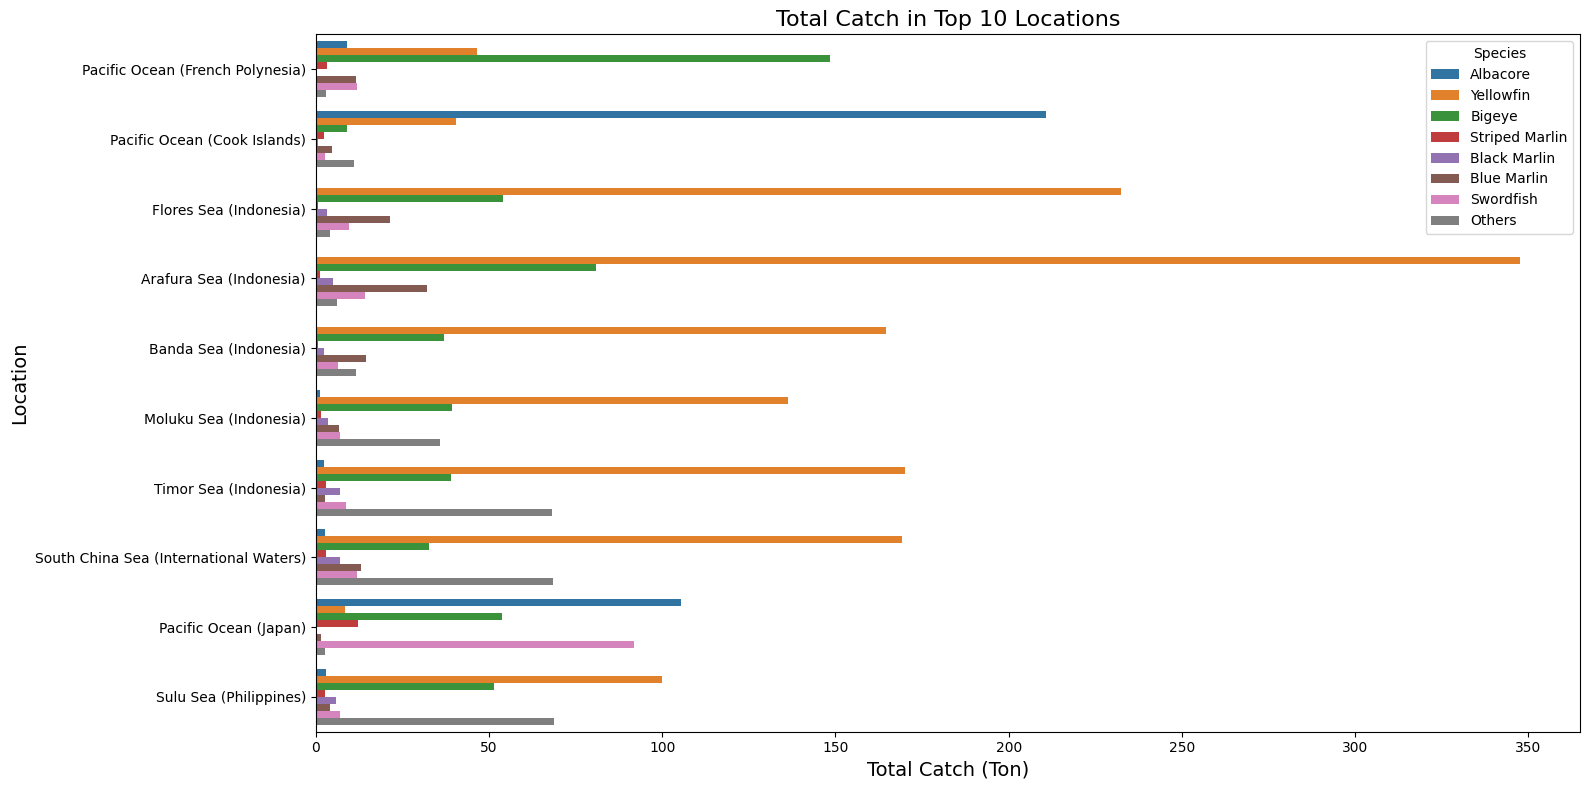

In [26]:
# Create a horizontal bar plot for total catch in top locations
plt.figure(figsize=(16, 8))  # Increase figure size for more space
sns.barplot(data=top_locations_melted, y='location', x='Total_Catch', hue='Species')

# Add title and labels
plt.title('Total Catch in Top 10 Locations', fontsize=16)
plt.ylabel('Location', fontsize=14)
plt.xlabel('Total Catch (Ton)', fontsize=14)
plt.legend(title='Species')
plt.tight_layout()  # Adjust layout to avoid overlapping elements
plt.savefig('total_catch_plot.png', dpi=300)
plt.show()




* **Variation in Total Catch Between Locations:** The graph shows significant variation in total catch between different locations. Some locations have total catches that are much higher than others.

* **Dominance of Several Species:** There are several species that consistently have higher total catches in most locations. This indicates that these species may be more commonly found or caught in those areas.

* **Interaction Between Locations and Species:** The graph also shows the interaction between locations and species. Some species may be more dominant in certain locations, while others are more dominant in different locations. It is observed that in locations around the Pacific Ocean near Japan and the Pacific Ocean near the Cook Islands, albacore is dominant, while yellowfin dominates in other locations.

## Fishing Dynamics: Annual Catch, Locations, and Hooks

In [27]:
# Set the 'date' column as the index for resampling
tuna_df.set_index('date', inplace=True)

# Resample to annual data and aggregate
annual_tuna_catch = tuna_df['yft_c'].resample('Y').sum().reset_index()  # Resample to yearly data
annual_hooks = tuna_df['hhooks'].resample('Y').sum().reset_index()  # Aggregate total hooks per year
annual_location_count = tuna_df.resample('Y').location.nunique().reset_index()  # Count unique locations per year

# Rename columns for clarity
annual_location_count.rename(columns={'date': 'yy', 'location': 'unique_location_count'}, inplace=True)


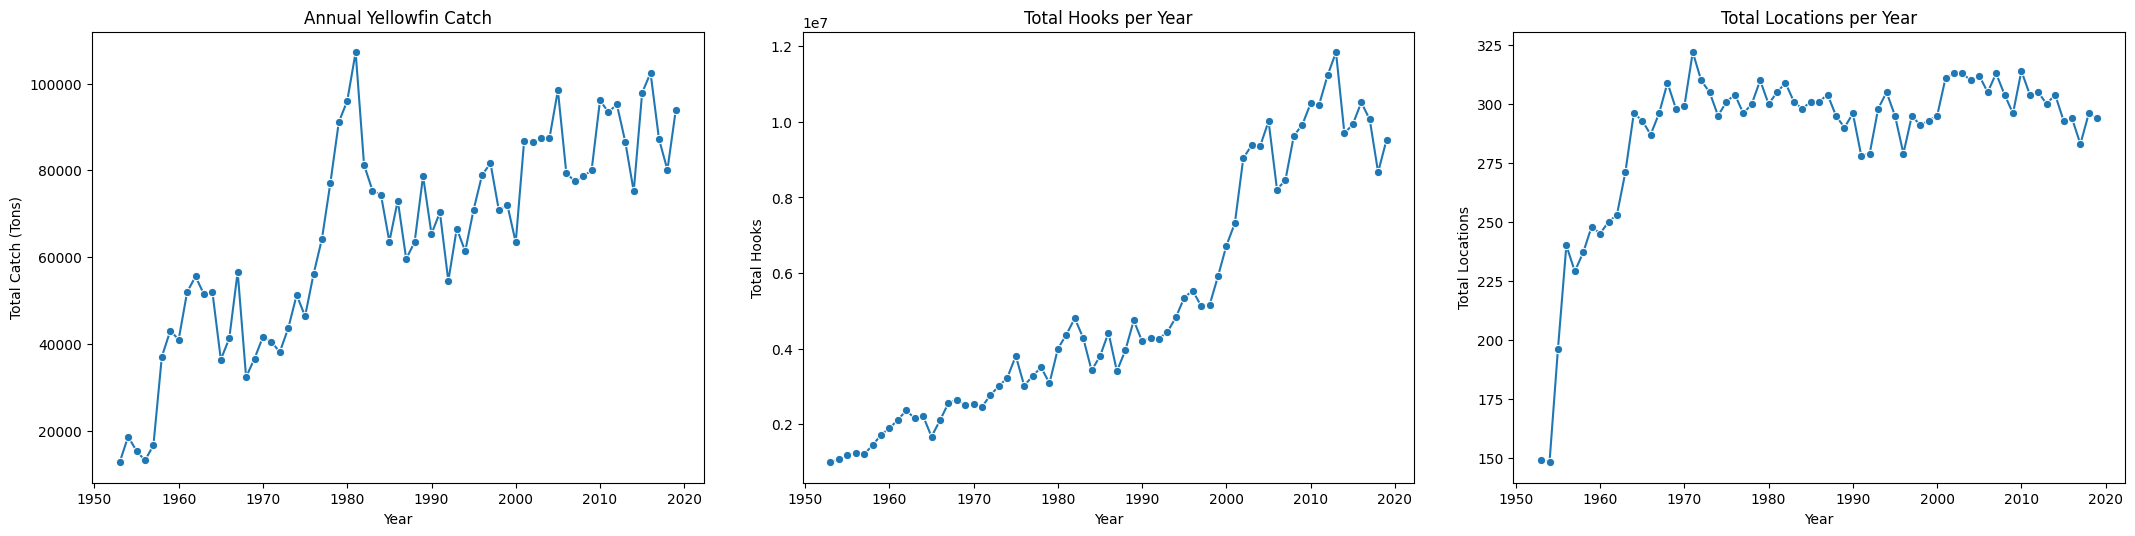

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(22, 6))

# Plot 1: Annual Yellowfin Catch
sns.lineplot(x=annual_tuna_catch['date'], y=annual_tuna_catch['yft_c'], marker='o', ax=ax[0])
ax[0].set_title('Annual Yellowfin Catch')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Total Catch (Tons)')
ax[0].tick_params(axis='x')

# Plot 2: Total Hooks per Year
sns.lineplot(x=annual_hooks['date'], y=annual_hooks['hhooks'], marker='o', ax=ax[1])
ax[1].set_title('Total Hooks per Year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Total Hooks')
ax[1].tick_params(axis='x')

# Plot 3: Total Locations per Year (using the 'yy' column for year)
sns.lineplot(x='yy', y='unique_location_count', data=annual_location_count, marker='o', ax=ax[2])
ax[2].set_title('Total Locations per Year')
ax[2].set_xlabel('Year')
ax[2].set_ylabel('Total Locations')
ax[2].tick_params(axis='x')

# Adjust layout to avoid overlap
fig.tight_layout(pad=3.0)

# Show the plots
plt.show()

**We can assume that the more hooks used, the greater the potential for fish catches, as well as with an increase in the number of locations. However, this relationship is not always linear. Other factors not included in this data also affect the catch results.**



# Dataset For Modeling

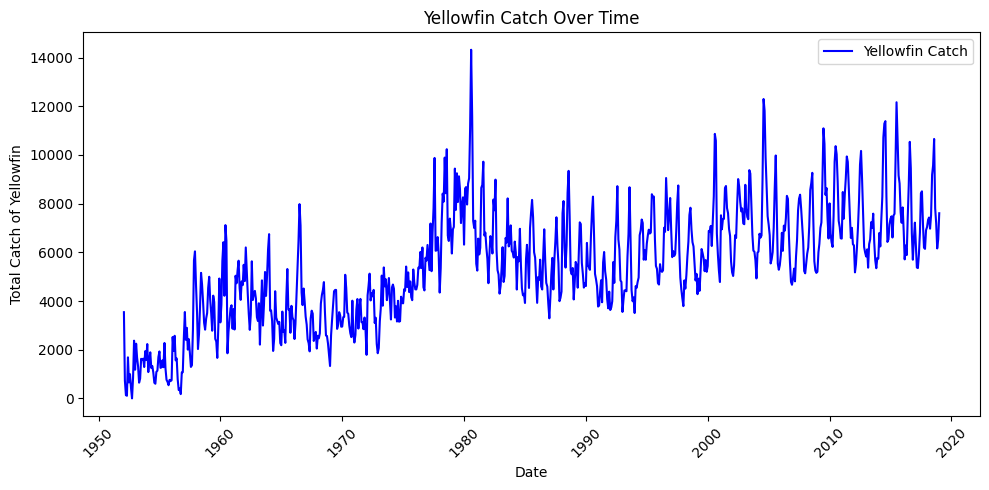

In [29]:
# Resample 'yft_c' to monthly sum
df_yellowfin = tuna_df['yft_c'].resample('M').sum()

# Plot Yellowfin catch over time
plt.figure(figsize=(10, 5))
plt.plot(df_yellowfin.index, df_yellowfin, label='Yellowfin Catch', color='blue')
plt.title('Yellowfin Catch Over Time')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Total Catch of Yellowfin')
plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of Yellowin')

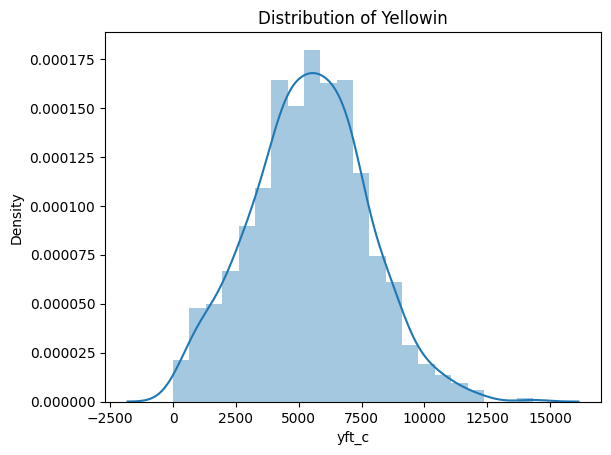

In [30]:
sns.distplot(df_yellowfin)
plt.title('Distribution of Yellowin')

**The distribution of yellowfin is already normally distributed, but there are still outliers present. I believe these outliers are still reasonable and valid, so there is no need to remove them.**

The data is already normally distributed and contains no outliers.

## Dataset for SARIMAX

### Seasonal Decompoese

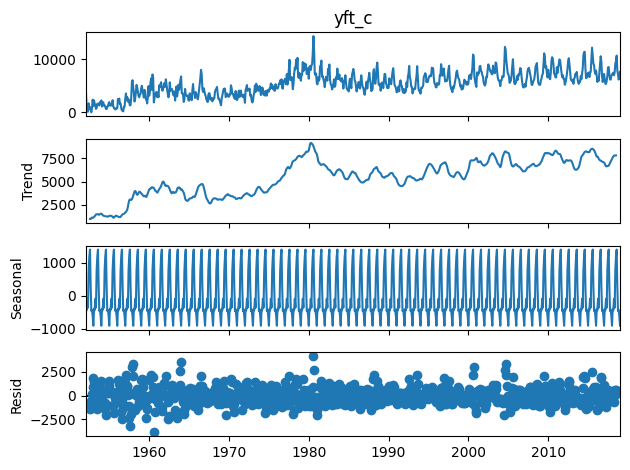

In [31]:
# Decompose the Yellowfin catch time series into seasonal components (additive model)
seasonal = seasonal_decompose(df_yellowfin, model='additive', period=12)
seasonal.plot() # Plot the seasonal decomposition
plt.show()


* **Tren :** Based on the graph, it appears that the trend component is generally increasing. This indicates that, overall, the catch values of yellowfin have been increasing over time.
* **Seasonal:** The seasonal component shows clear and recurring fluctuations. This indicates a strong seasonal pattern in the yellowfin catch data. This seasonal pattern could be due to factors such as seasonal changes, weather, or other natural cycles.
* **Residual :** The residual component appears relatively random and is distributed around zero. This suggests that most of the variation in the data has been successfully explained by the trend and seasonal components.

### Stationarity Check

In [32]:
# Function to plot rolling mean and standard deviation
def TestStationaryPlot(ts):
    # Calculate rolling mean and standard deviation with a 12-period window
    rol_mean = ts.rolling(window=12).mean()
    rol_std = ts.rolling(window=12).std()

    # Plot the original data, rolling mean, and rolling standard deviation
    plt.figure(figsize=(12, 6))
    plt.plot(ts.index, ts, label='Original Data', color='blue', marker='o', markersize=3)
    plt.plot(ts.index, rol_mean, label='Rolling Mean', color='black', linewidth=2)
    plt.plot(ts.index, rol_std, label='Rolling Standard Deviation', color='brown', linewidth=2)
    plt.title('Rolling Mean & Standard Deviation', fontsize=16)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Value', fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

In [33]:
# Function for ADF (Augmented Dickey-Fuller) test
def adf_test(timeseries):
    # Perform the Dickey-Fuller test
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='BIC', regression='c')  # Test with BIC and constant regression
    # Extract and display test statistic, p-value, lags, and number of observations
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    # Display critical values for different confidence levels
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    print(dfoutput)

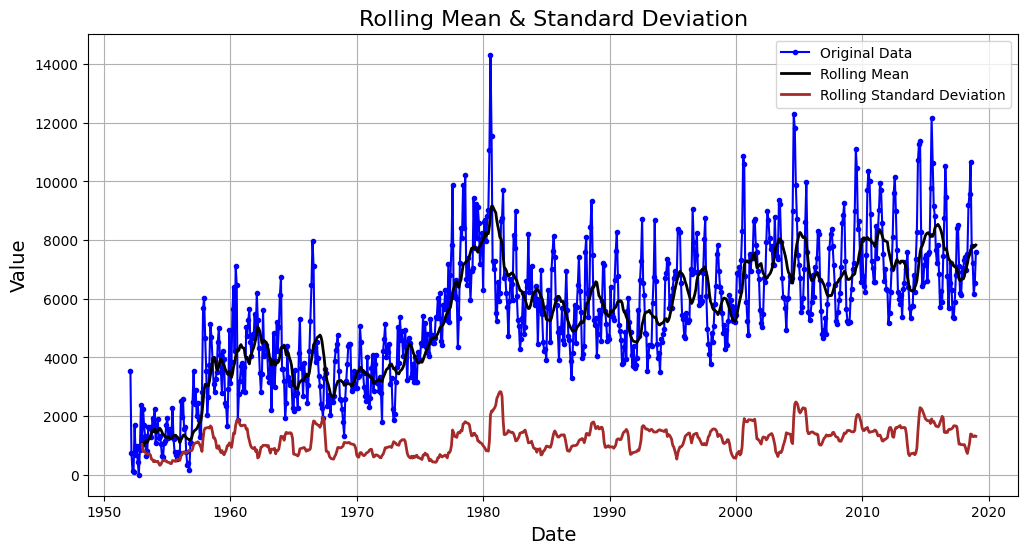

Results of Dickey-Fuller Test:
Test Statistic                  -2.489094
p-value                          0.118150
#Lags Used                      12.000000
Number of Observations Used    791.000000
Critical Value (1%)             -3.438644
Critical Value (5%)             -2.865201
Critical Value (10%)            -2.568719
dtype: float64


In [34]:
TestStationaryPlot(df_yellowfin)
adf_test(df_yellowfin.dropna())

**The graph indicates a long-term upward trend in the data, with significant seasonal fluctuations and considerable variability. This data is non-stationary, necessitating special handling in further analysis.**

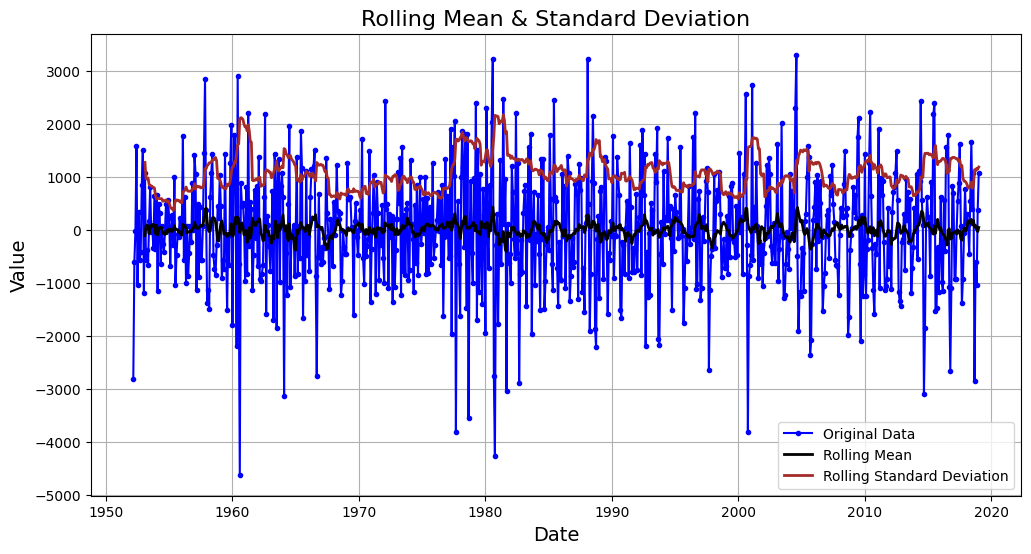

Results of Dickey-Fuller Test:
Test Statistic                -1.214454e+01
p-value                        1.622081e-22
#Lags Used                     1.100000e+01
Number of Observations Used    7.910000e+02
Critical Value (1%)           -3.438644e+00
Critical Value (5%)           -2.865201e+00
Critical Value (10%)          -2.568719e+00
dtype: float64


In [35]:
# Calculate the first difference of the Yellowfin catch and drop NaN values
df_diff = df_yellowfin.diff().dropna()
TestStationaryPlot(df_diff)
adf_test(df_diff)

**After differencing, the results of the ADF test indicate that the data has become stationary, as evidenced by the p-value being less than 0.05.**

### Plot ACF and PACF

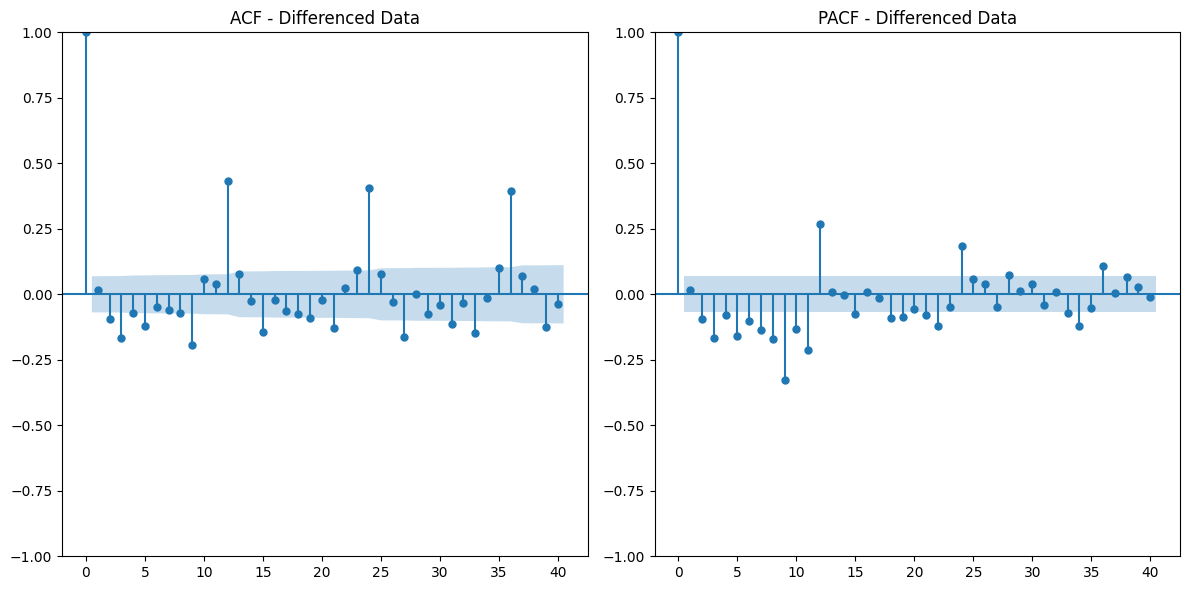

In [36]:
# Plot ACF and PACF for differenced data
plt.figure(figsize=(12, 6))

# ACF plot
plt.subplot(121)
plot_acf(df_diff, lags=40, ax=plt.gca())
plt.title('ACF - Differenced Data')

# PACF plot
plt.subplot(122)
plot_pacf(df_diff, lags=40, ax=plt.gca())
plt.title('PACF - Differenced Data')

# Adjust layout and display
plt.tight_layout()
plt.show()


* p: 1 (because there is a significant spike at the first lag in the PACF)
* d: 1 (because the data has been differenced once)
* q: 0 (because the ACF quickly decreases after the first lag)
* P: 1 (because there may be a seasonal pattern at lag 12)
* D: 1 (if additional seasonal differencing is required)
* Q: 0 (because there is no strong indication for seasonal MA)
* s: 12 (because of the assumption of annual seasonality)

**However, it still requires further iteration to refine the representation.**





## Dataset for Prophet

In [37]:
prophet_data = df_yellowfin.reset_index()  # Reset index if the date is the index
prophet_data.rename(columns={'date': 'ds', 'yft_c': 'y'}, inplace=True)
prophet_data['ds'] = pd.to_datetime(prophet_data['ds'])
prophet_data

,ds,y
0,1952-01-31,3543.954
1,1952-02-29,732.024
2,1952-03-31,136.148
3,1952-04-30,112.176
4,1952-05-31,1689.677
...,...,...
799,2018-08-31,7808.591
800,2018-09-30,7206.675
801,2018-10-31,6162.228
802,2018-11-30,6535.527


## Split Data (test & train)

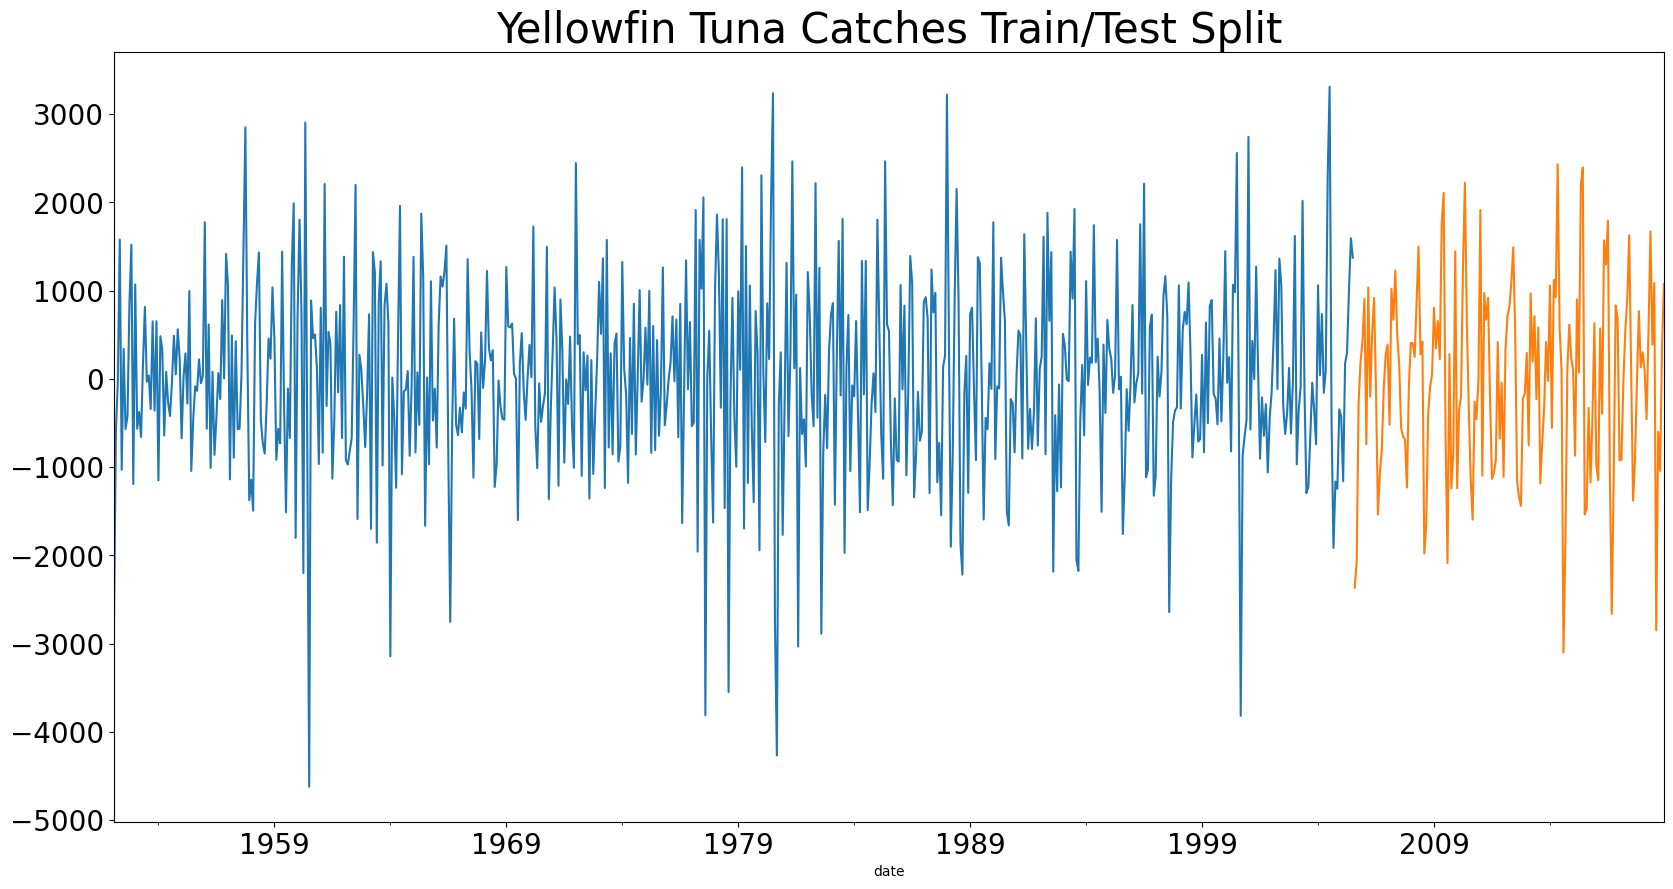

In [38]:
# Split data into training and testing sets (80% train, 20% test)
train_size = int(len(df_diff) * 0.8)

# Use iloc[] to split the data based on numeric position
train = df_diff.iloc[:train_size]
test = df_diff.iloc[train_size:]

# Plot train and test data
train.plot(figsize=(20, 10), fontsize=20)
plt.title('Yellowfin Tuna Catches Train/Test Split', fontsize=30)
test.plot()
plt.show()

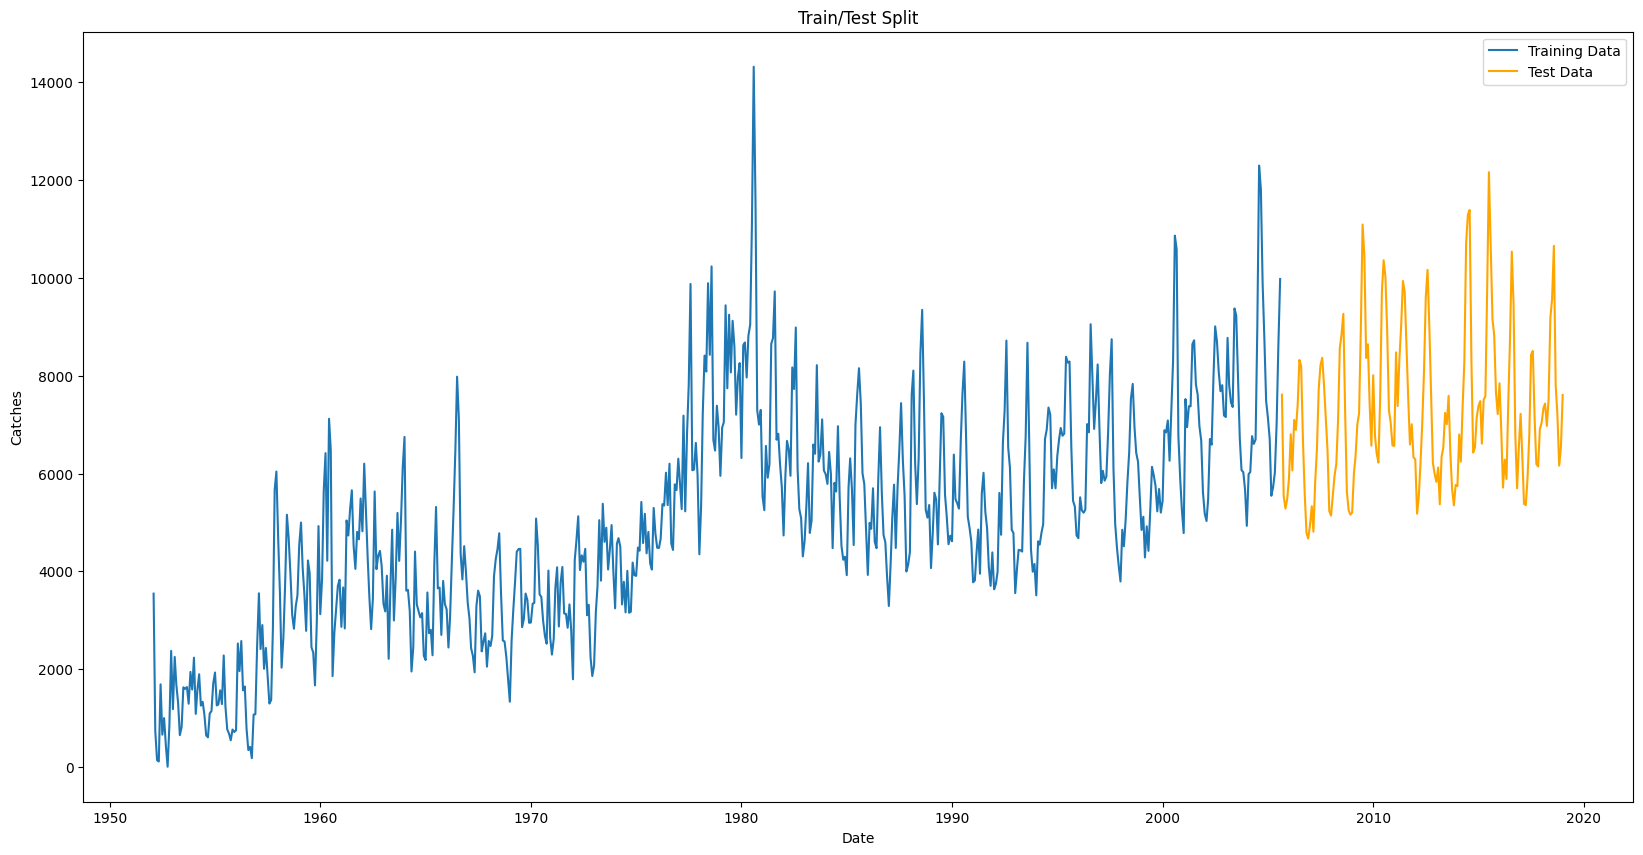

In [39]:
# Split data into training and testing sets prophet data
train_size = int(len(prophet_data) * 0.8)
train_data = prophet_data.iloc[:train_size]
test_data = prophet_data.iloc[train_size:]

# Convert 'ds' column to datetime for train data
train_data['ds'] = pd.to_datetime(train_data['ds'])

# Plot train/test split
plt.figure(figsize=(20, 10))
plt.plot(train_data['ds'], train_data['y'], label='Training Data')
plt.plot(test_data['ds'], test_data['y'], label='Test Data', color='orange')
plt.title('Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Catches')
plt.legend()
plt.show()


# Modeling

## Modeling with Auto Arima

In [40]:
model_auto_arima = auto_arima(train, seasonal=True, m=12, stepwise=True, trace=True)
print(model_auto_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=4.62 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=10792.448, Time=0.08 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=10672.368, Time=0.98 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=10713.354, Time=0.94 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=10790.504, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=10792.888, Time=0.07 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=10634.142, Time=6.50 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=10571.295, Time=6.13 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=10569.529, Time=2.49 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=10718.560, Time=0.35 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=8.05 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=10681.561, Time=2.41 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=9.79 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=10573.788, Time=1.60 sec
 ARIMA(2,0,0)(1,0,1)[12

Mean Squared Error (MSE): 710410.2250580214
Root Mean Squared Error (RMSE): 842.8583659536289
Mean Absolute Error (MAE): 670.0630573926775


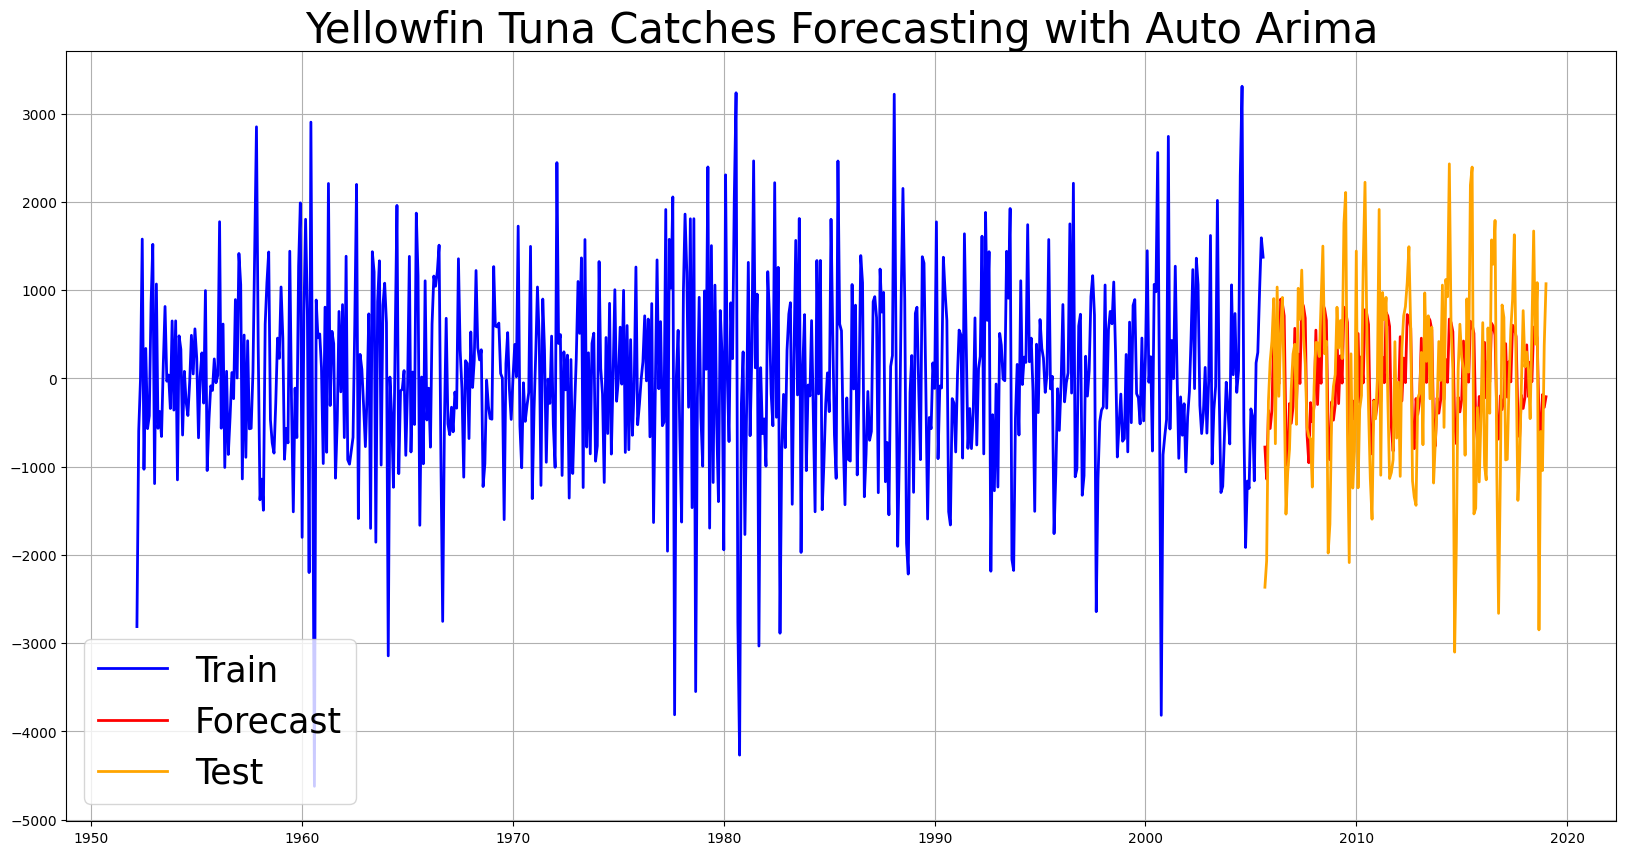

In [41]:
# Define forecast length
fcast_len = len(test)  # Length of the test data

# Generate forecast using ARIMA model
fcast_auto = model_auto_arima.predict(n_periods=fcast_len)  # Prediction for the test period

# Calculate error metrics
mse = mean_squared_error(test, fcast_auto)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test, fcast_auto)

# Plotting the results
plt.figure(figsize=(20, 10))
plt.title('Yellowfin Tuna Catches Forecasting with Auto Arima', fontsize=30)

# Plot the training data in blue
plt.plot(train, label='Train', color='blue', linewidth=2)

# Plot the forecasted data in red
plt.plot(test.index, fcast_auto, label='Forecast', color='red', linewidth=2)

# Plot the actual test data in orange
plt.plot(test, label='Test', color='orange', linewidth=2)

# Displaying the error metrics
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')

# Adding legend and setting font size
plt.legend(fontsize=25)

# Show grid and plot
plt.grid(True)
plt.show()


## Modeling with Sarima

Mean Squared Error (MSE): 681957.0368393324
Root Mean Squared Error (RMSE): 825.8069004551442
Mean Absolute Error (MAE): 659.9164417693017


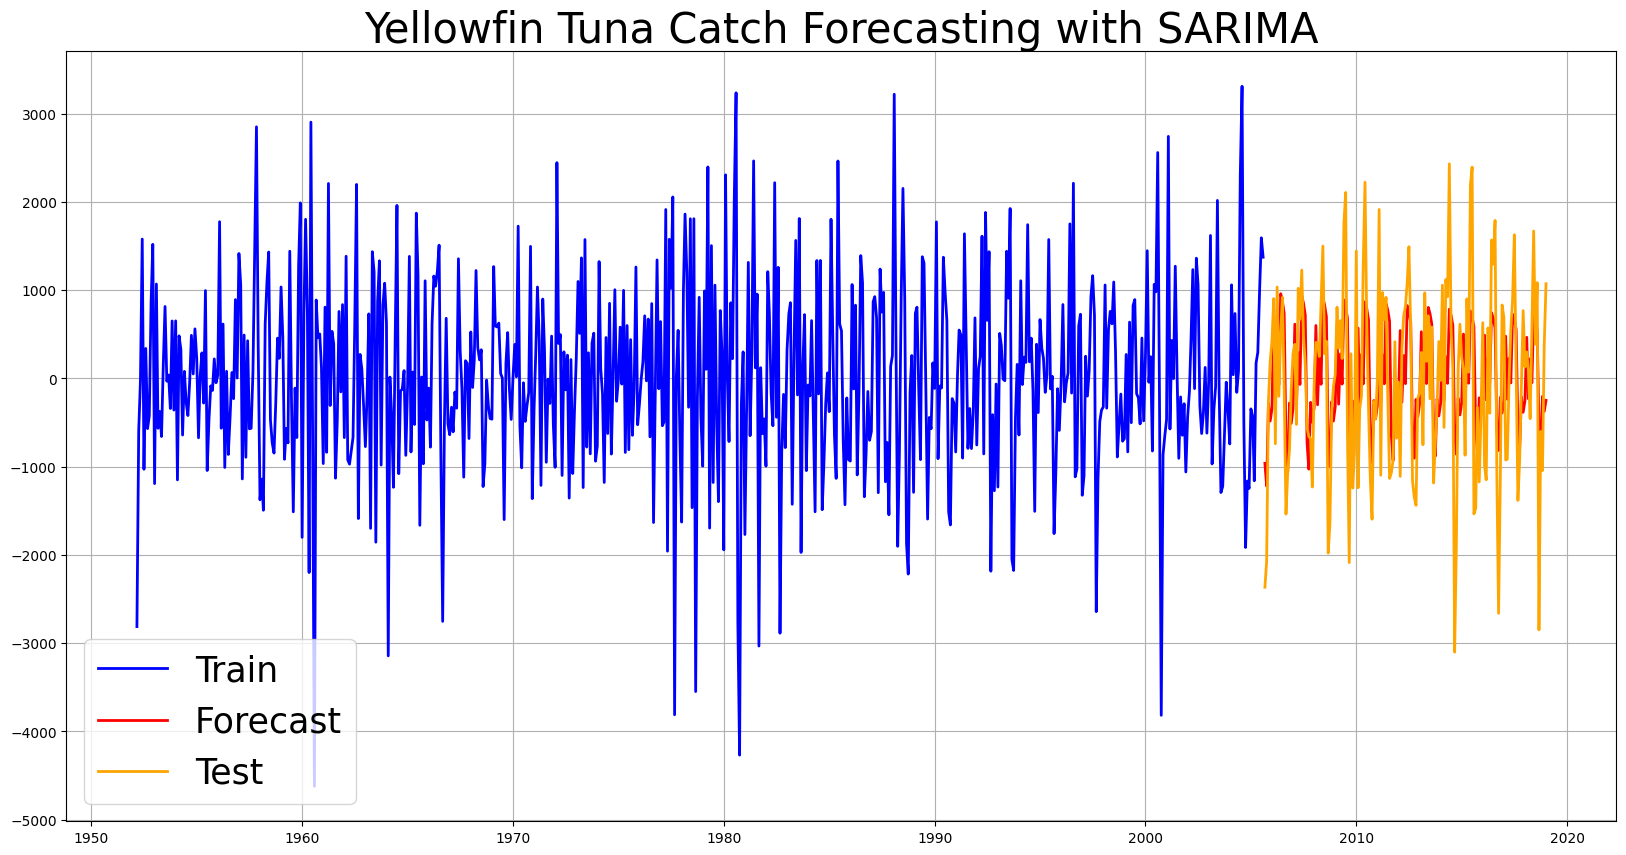

In [42]:
# Fit the SARIMAX model
model_sarimax = SARIMAX(train, order=(3, 1, 1), seasonal_order=(1, 0, 1, 12))
model_fit = model_sarimax.fit(disp=False)

# Generate forecast for the test period
fcast_len = len(test)  # Length of the test data
fcast = model_fit.forecast(fcast_len)  # Forecasting for the test period

# Calculate error metrics for SARIMAX model
mse_sarima = mean_squared_error(test, fcast)  # Mean Squared Error
rmse_sarima = np.sqrt(mse_sarima)  # Root Mean Squared Error
mae_sarima = mean_absolute_error(test, fcast)  # Mean Absolute Error

# Displaying the error metrics
print(f'Mean Squared Error (MSE): {mse_sarima}')
print(f'Root Mean Squared Error (RMSE): {rmse_sarima}')
print(f'Mean Absolute Error (MAE): {mae_sarima}')

# Plotting the results
plt.figure(figsize=(20, 10))
plt.title('Yellowfin Tuna Catch Forecasting with SARIMA', fontsize=30)

# Plot the training data in blue
plt.plot(train, label='Train', color='blue', linewidth=2)

# Plot the forecasted data in red
plt.plot(test.index, fcast, label='Forecast', color='red', linewidth=2)

# Plot the actual test data in orange
plt.plot(test, label='Test', color='orange', linewidth=2)

# Adding legend and setting font size
plt.legend(fontsize=25)

# Show grid and plot
plt.grid(True)
plt.show()



## Modeling with Prophet

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpeb9minxk/zuyhx5b3.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpeb9minxk/evwzj0ei.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=75838', 'data', 'file=/tmp/tmpeb9minxk/zuyhx5b3.json', 'init=/tmp/tmpeb9minxk/evwzj0ei.json', 'output', 'file=/tmp/tmpeb9minxk/prophet_model68e3nxgq/prophet_model-20250113005516.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
00:55:16 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
00:55:16 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Mean Squared Error (MSE): 710410.2250580214
Root Mean Squared Error (RMSE): 842.8583659536289
Mean Absolute Error (MAE): 670.0630573926775


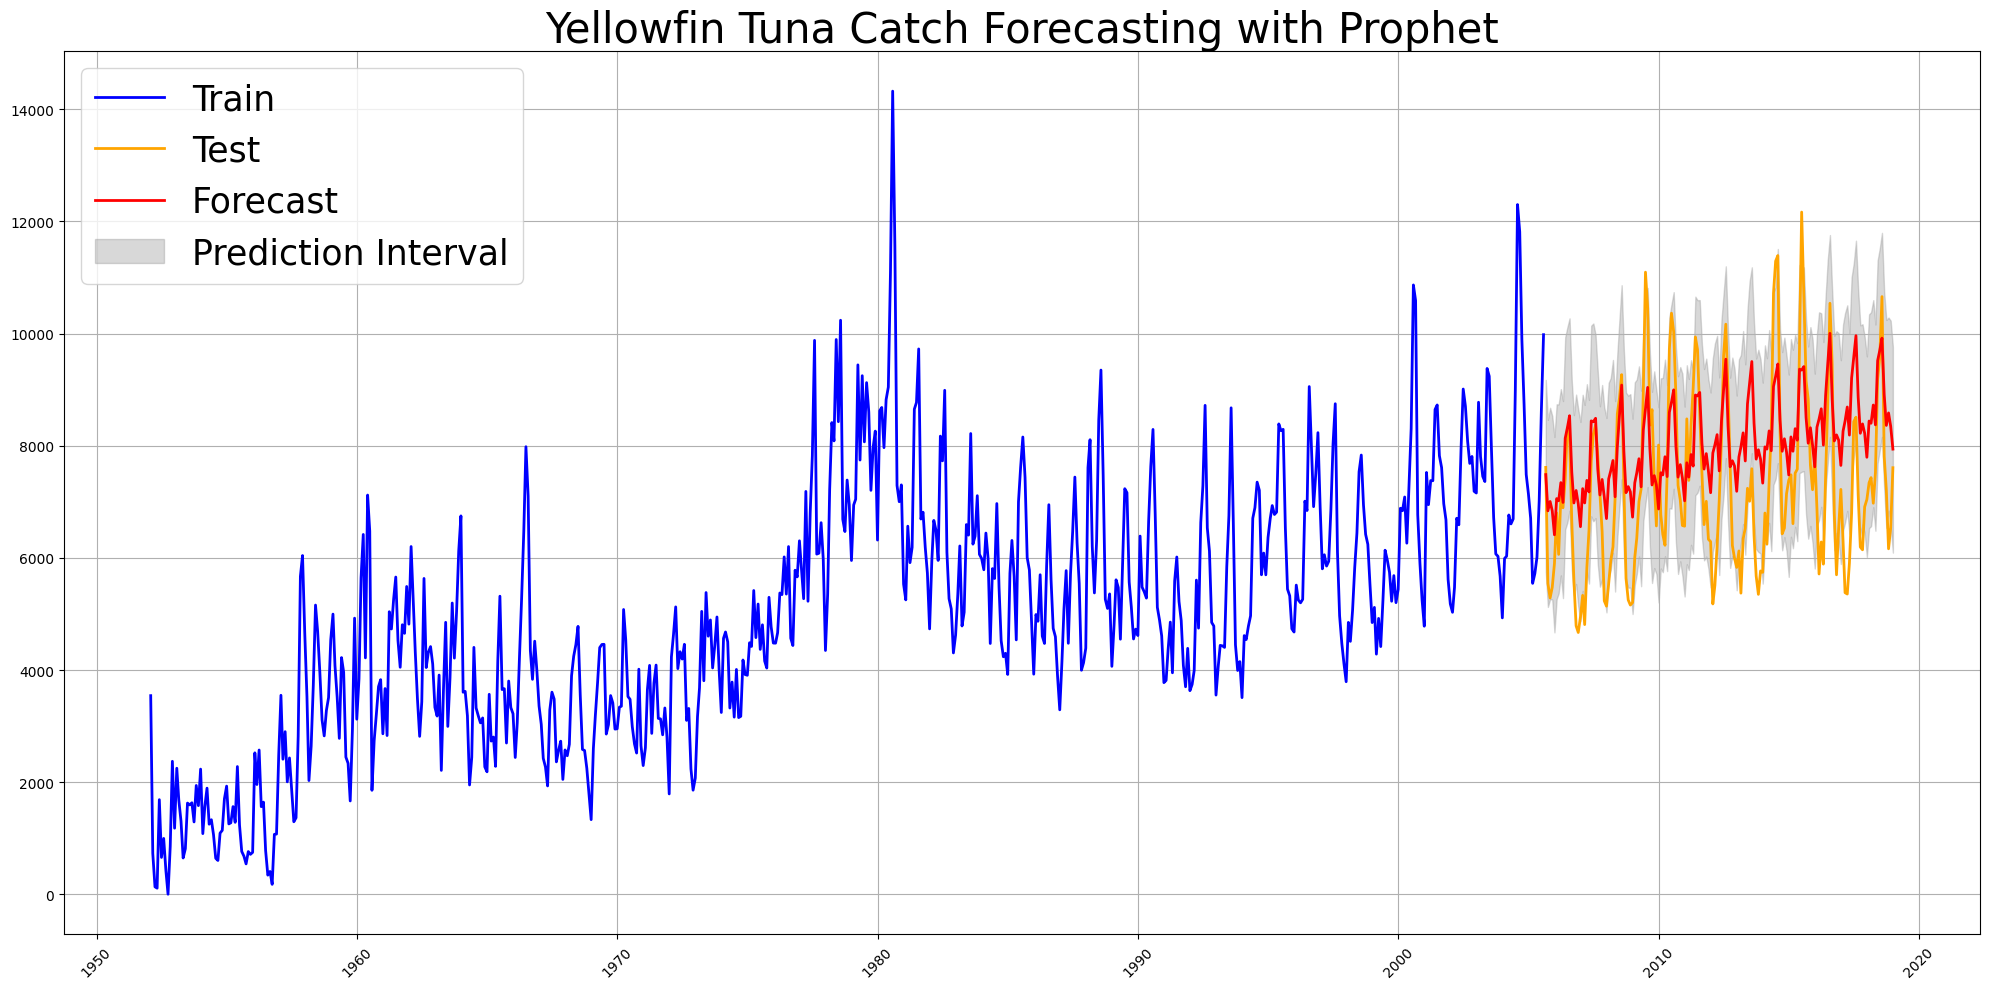

In [43]:
# Create Prophet model with additive seasonality and yearly seasonality
model = Prophet(seasonality_mode='additive', yearly_seasonality=True)

# Train the model on the training data
model.fit(train_data)

# Predict using the test data
forecast = model.predict(test_data)

# Calculate evaluation metrics
mse_prop = mean_squared_error(test_data['y'], forecast['yhat'])
rmse_prop = np.sqrt(mse)
mae_prop = mean_absolute_error(test_data['y'], forecast['yhat'])

# Display evaluation metrics
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'Mean Absolute Error (MAE): {mae}')

# Create the plot with larger size
plt.figure(figsize=(20, 10))
plt.title('Yellowfin Tuna Catch Forecasting with Prophet', fontsize=30)

# Plot training data in blue
plt.plot(train_data['ds'], train_data['y'], label='Train', color='blue', linewidth=2)

# Plot actual test data in orange
plt.plot(test_data['ds'], test_data['y'], label='Test', color='orange', linewidth=2)

# Plot forecast predictions in red
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red', linewidth=2)

# Add uncertainty range (yhat_upper and yhat_lower)
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='gray', alpha=0.3, label='Prediction Interval')

# Add legend with uniform font size
plt.legend(fontsize=25)

# Add grid, rotate x-axis labels, and adjust layout
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

## Metrics Evaluation

In [44]:
metrics = ['MAE', 'MSE', 'RMSE']
auto_arima_values = [mae, mse, rmse]
sarimax_values = [mae_sarima, mse_sarima, rmse_sarima]
prophet_values = [mae_prop, mse_prop, rmse_prop]

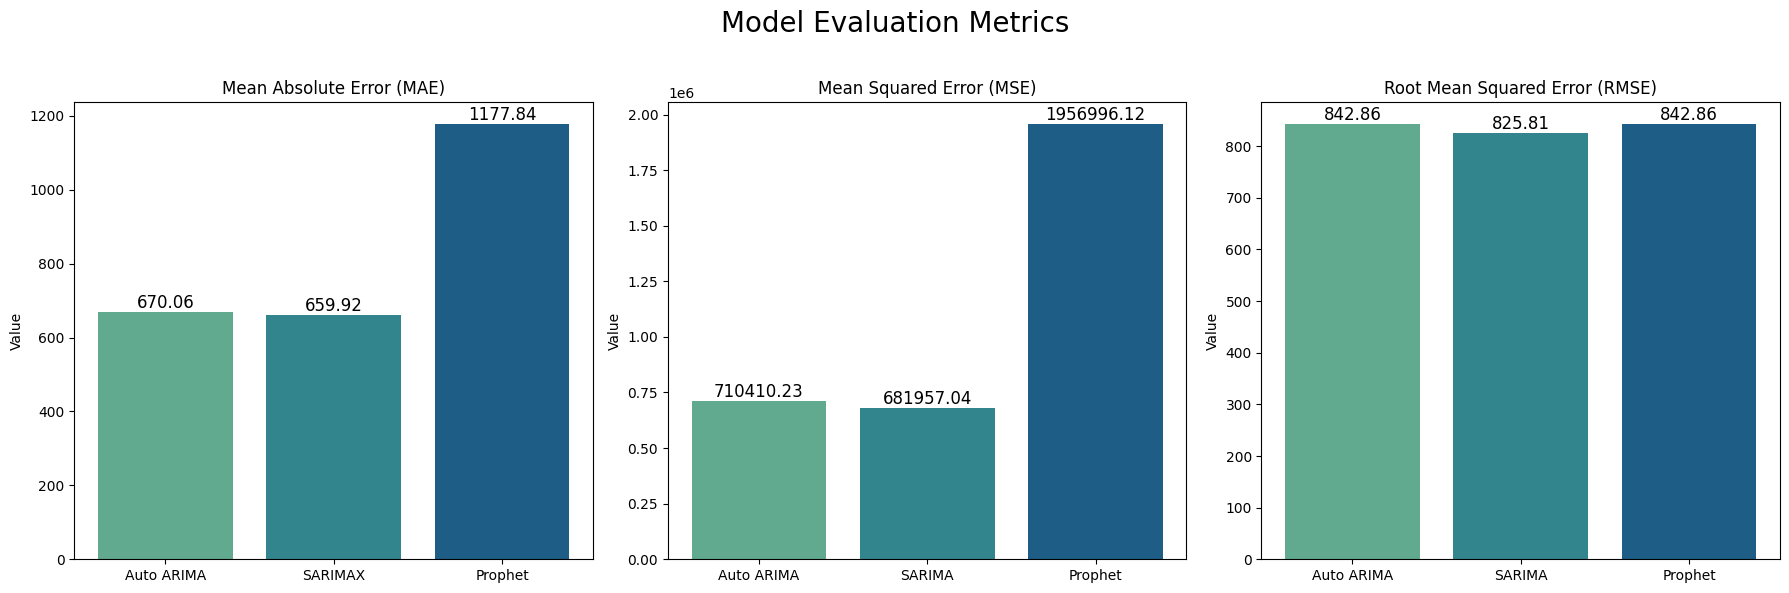

In [53]:
colors = sns.color_palette("crest", 3)

# Create subplots: 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 6))  # Adjust layout to 1 row, 3 columns

# Main title for the entire figure
fig.suptitle('Model Evaluation Metrics', fontsize=20)

# Bar plot for MAE
bars_mae = axs[0].bar(['Auto ARIMA', 'SARIMAX', 'Prophet'], [mae, mae_sarima, mae_prop], color=colors)
axs[0].set_title('Mean Absolute Error (MAE)')
axs[0].set_ylabel('Value')

# Add labels for MAE bars
for bar in bars_mae:
    yval = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width() / 2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom', fontsize=12)

# Bar plot for MSE
bars_mse = axs[1].bar(['Auto ARIMA', 'SARIMA', 'Prophet'], [mse, mse_sarima, mse_prop], color=colors)
axs[1].set_title('Mean Squared Error (MSE)')
axs[1].set_ylabel('Value')

# Add labels for MSE bars
for bar in bars_mse:
    yval = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width() / 2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom', fontsize=12)

# Bar plot for RMSE
bars_rmse = axs[2].bar(['Auto ARIMA', 'SARIMA', 'Prophet'], [rmse, rmse_sarima, rmse_prop], color=colors)
axs[2].set_title('Root Mean Squared Error (RMSE)')
axs[2].set_ylabel('Value')

# Add labels for RMSE bars
for bar in bars_rmse:
    yval = bar.get_height()
    axs[2].text(bar.get_x() + bar.get_width() / 2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom', fontsize=12)

# Adjust layout to avoid overlap with suptitle
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('model_evaluation_metrics.png', dpi=300)

# Show the plots
plt.show()

Based on the evaluation metric graphs, SARIMA is the best model according to the lower MAE and MSE. Since the goal is forecasting to minimize forecast errors, SARIMA Model 2 is the most suitable, even though Prophet has the highest R², indicating that it explains the variation in the data well. However, its performance is not the best in terms of error.

# Result  

## Implementing Forecasting with the Best Model

In [46]:
# Fit the SARIMAX model
model_best = SARIMAX(df_diff, order=(3, 1, 1), seasonal_order=(1, 0, 1, 12))
results_best = model_best.fit()

# Forecast for the next 12 periods
forecast_steps = 12
forecast_best = results_best.get_forecast(steps=forecast_steps)

# Generate forecast index (dates for future predictions)
forecast_index = pd.date_range(start=df_diff.index[-1] + pd.DateOffset(months=1),
                                 periods=forecast_steps, freq='M')

# Extract forecast values and confidence intervals
forecast_values = forecast_best.predicted_mean
confidence_intervals = forecast_best.conf_int()

# Get the last observation from the original series (not differenced data)
last_observation = df_yellowfin.iloc[-1]  # Use original data for the starting point

# Accumulate predicted values
predicted_values = []
for i, value in enumerate(forecast_values):
    last_observation += value  # Add forecast value to the last observation
    predicted_values.append(last_observation)

# Generate predicted index (dates for forecasted values)
predicted_index = pd.date_range(start=df_diff.index[-1] + pd.DateOffset(months=1),
                                 periods=forecast_steps, freq='M')
predicted_series = pd.Series(predicted_values, index=predicted_index)

# Calculate the lower and upper bounds for the forecast intervals
lower_bounds = confidence_intervals.iloc[:, 0] + predicted_values[0]
upper_bounds = confidence_intervals.iloc[:, 1] + predicted_values[0]

# Create a DataFrame with forecast values and confidence intervals
forecast_df = pd.DataFrame({
    'Forecast': predicted_series,
    'Lower Bound': lower_bounds,
    'Upper Bound': upper_bounds
})

# Sort the DataFrame by forecast values in descending order
forecast_df_sorted = forecast_df.sort_values(by='Forecast', ascending=False)

# Display the results
print(forecast_df_sorted)


                Forecast  Lower Bound   Upper Bound
2019-07-31  10215.688006  5679.058011   9987.271928
2019-06-30   9918.479096  6285.844430  10594.007510
2019-05-31   9014.509186  6739.861025  11047.654246
2019-08-31   8677.653656  3843.794531   8152.048889
2019-04-30   7656.707611  5761.393207  10065.794261
2019-09-30   7623.279771  4327.454550   8635.709801
2019-01-31   7535.956060  5354.875718   9574.564523
2019-12-31   7492.047401  5703.957003  10012.216351
2019-03-31   7279.069936  5739.111335  10040.399443
2019-11-30   7169.916783  5486.611037   9794.870543
2019-10-31   7065.132053  4823.678704   9131.937980
2019-02-28   6925.270607  4797.441639   9053.099575


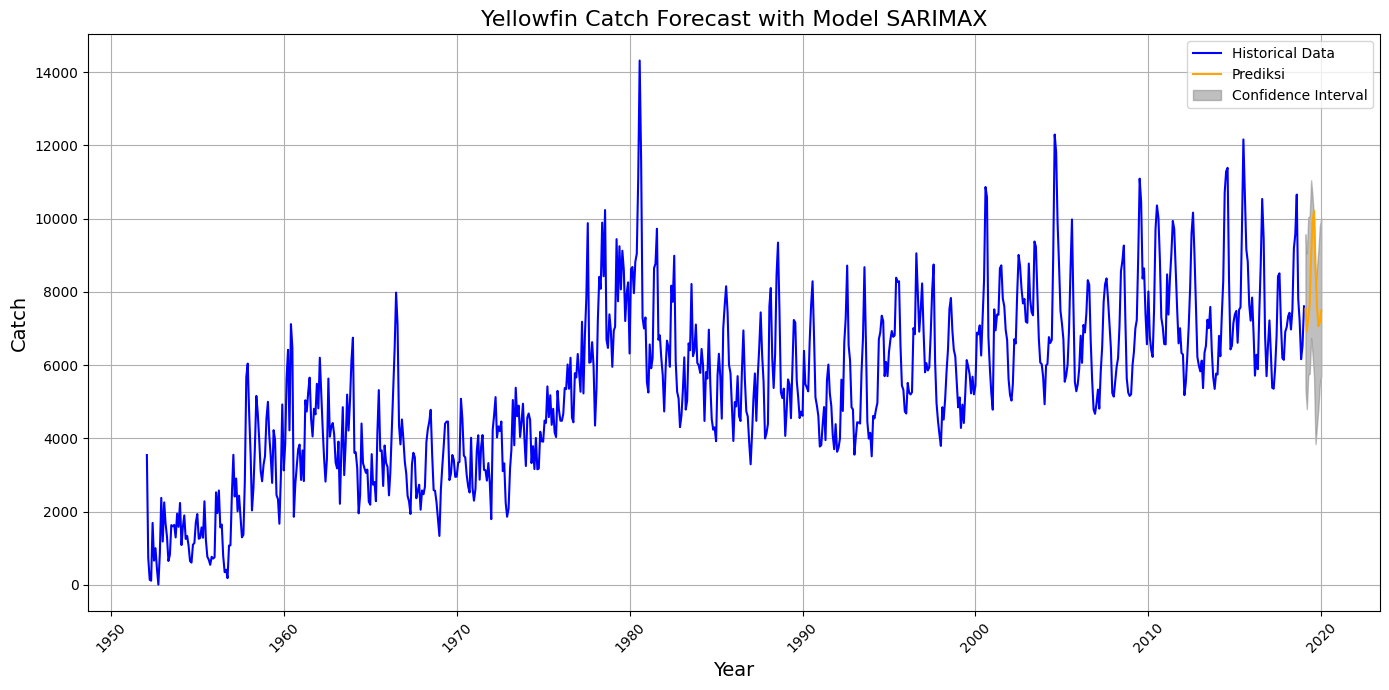

In [47]:
# Plot historical data, forecast, and confidence interval
plt.figure(figsize=(14, 7))

# Historical data
plt.plot(df_yellowfin.index, df_yellowfin, label='Historical Data', color='blue')

# Forecasted values
plt.plot(predicted_series.index, predicted_series, label='Prediksi', color='orange')

# Confidence interval
plt.fill_between(predicted_series.index, lower_bounds, upper_bounds, color='gray', alpha=0.5, label='Confidence Interval')

# Title and labels
plt.title('Yellowfin Catch Forecast with Model SARIMAX', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Catch', fontsize=14)

# Legend, x-ticks rotation, layout, and grid
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()

Based on the forecasting results, the optimal months for yellowfin tuna catching are as follows:

* **July** : The highest forecast for yellowfin tuna catch, with 10,215.69 tons. This is the peak month for catching yellowfin tuna based on the forecasting results.
* **June** : With a forecast of 9,918.48 tons, this is another strong month for catching yellowfin tuna, just slightly lower than July.
* **May** : Forecast of 9,014.51 tons, indicating a good opportunity for catching yellowfin tuna.

# Conclusion

* **Dominant Species:**
Yellowfin tuna is the dominant species, contributing the most to total fish catches, followed by bigeye and albacore. Other species contribute significantly less.

* **Trends Over Time:**
Total catches increased significantly until the 1990s, after which they stabilized, indicating improvements in fishery management.

* **Seasonal Fluctuations:**
The catch data shows seasonal variations, with certain species peaking in specific months.

* **Location Variability:**
Different fishing locations exhibit significant variation in total catches, with some locations dominating specific species.

* **Increased Fishing Gear:**

The rise in fishing gear has led to higher total catches, indicating an expansion of fishing areas to meet market demand.

* **Forecasting Model:**
The SARIMA model outperformed the Prophet model in forecasting accuracy, although the Prophet model was effective in explaining data variation.

# Business Recomendation

1. Focus on May to July: The forecast data indicates that May to July are projected to have the highest catch volumes. Plan intensive fishing activities during these months to maximize yields.

2. Stock Preparation: Given the high catch projections, ensure that equipment and supplies (such as fishing gear) are sufficiently available. This will help minimize downtime and maximize operational efficiency during peak fishing periods.

3. Expand Species Range: Considering that several other species contribute relatively higher catches, consider diversifying by targeting species beyond the peak yellowfin catching period.

4. Target High-Potential Areas: Locations with high potential, such as 05S, 125E; 05S, 120E; 30N, 140E; 15N, 115E; and 05N, 130E should be prioritized. Allocate resources and equipment to reach these areas to enhance catch outcomes.